In [1]:
import copy
import numpy as np
import pickle

In [2]:
from plant_model import GroupOfElectrolysers
from reference_trajectrory_source_model import ReferenceTrajectorySource
from controller_model import Controller
from control_assessment_model import ControlAssessment

In [3]:
from controller_NeuroEvolutional import Agent
# from controller_NeuroEvolutional_2elec import Agent as Agent_2elec

In [4]:
# from controller_MPC import MPC

In [5]:
from controller_heuristic import ControllerHeuristic

In [6]:
## simulation setup
HOUR_TO_SEC = 60 * 60

HOURS_IN_SIMULATION = 12
SIMULATION_TIME = HOURS_IN_SIMULATION * HOUR_TO_SEC
SAMPLING_TIME_PLANT = 8
SAMPLING_TIME_PLAN = 15 * 60
SAMPLING_TIME_CONTROL = 15 * 60

STEPS_IN_EPISODE = SIMULATION_TIME // SAMPLING_TIME_PLANT

HOURS_IN_PLANING_HORIZON = 6
PLANING_HORIZON = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC // SAMPLING_TIME_PLAN

# HOURS_IN_CONTROL_HORIZON = HOURS_IN_SIMULATION
# CONTROL_HORIZON = HOURS_IN_CONTROL_HORIZON * HOUR_TO_SEC // SAMPLING_TIME_CONTROL

NUMBER_OF_ELECTROLYSERS = 5
ELECTROLYSER_MAX_POWER = 2400

In [7]:
def episode_simulation(plant, reference_source, controller, steps_in_episode):
    sampling_time_plant = plant.sampling_time
    sampling_time_plan = reference_source.sampling_time
    sampling_time_control = controller.sampling_time
    trajectory_reference = []
    trajectory = []
    control_strategy = np.zeros((1, plant.number_of_electrolysers))
    for k in range(steps_in_episode):
        ## snap current state of the control system
        plant_state = plant.group_state
        if int(k * sampling_time_plant) % sampling_time_plan == 0: # every 15 minutes
            plan = reference_source.form_plan(instant = k)
            assert len(plan) == PLANING_HORIZON, "len(plan) != PLANING_HORIZON"
        if int(k * sampling_time_plant) % sampling_time_control == 0: # every 30 minutes
            control = controller.form_control(instant = k, plant = copy.deepcopy(plant), plan = plan)
            control_strategy = np.vstack((control_strategy, control))
        ## log simulation data
        [group_output,
         set_points,
         outputs,
         output_derives,
         temperatures,
         stack_states,
         group_deterioration] = plant_state
        trajectory_reference.append(plan[0])
        trajectory.append(group_output)
        ## make step of dynamics
        plant.make_dynamical_step(control)
    control_strategy = np.delete(control_strategy, 0, 0)
    return np.array(trajectory_reference), np.array(trajectory), np.array(group_deterioration), control_strategy

In [8]:
# mpc = MPC(PLANING_HORIZON, SAMPLING_TIME_CONTROL, SAMPLING_TIME_PLANT, SAMPLING_TIME_PLAN)

In [9]:
file_params = open('neuro_evolutional_model_serialized/best_params.pkl', 'rb')
best_solution = pickle.load(file_params)
file_params.close()
agent = Agent()
agent.updateParams(best_solution)

# file_params = open('neuro_evolutional_model_serialized/best_solution_2elec.pkl', 'rb')
# best_solution = pickle.load(file_params)
# file_params.close()
# agent = Agent_2elec()
# agent.updateParams(best_solution)

In [10]:
heuristic = ControllerHeuristic(PLANING_HORIZON, SAMPLING_TIME_CONTROL, SAMPLING_TIME_PLANT, SAMPLING_TIME_PLAN)

In [22]:
## User-Defined control policy
def policy(instant: int,
           plant_model_copy: np.ndarray,
           plan: np.ndarray,
           control_signal_dimension: int) -> np.ndarray:

    ## constant demo control
    # control = np.ones(control_signal_dimension) * plan[0] / 5

    # MPC control
    # if ((instant * SAMPLING_TIME_PLANT) % (HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC)) == 0: # every 6 hours
    #     # print("=============== MPC UPDATE =======================")
    #     mpc.form_control_strategy_for_plan(instant = instant,
    #                                        plant_model_copy = plant_model_copy,
    #                                        plan = plan,
    #                                        control_signal_dimension = control_signal_dimension)
    # control_strategy = mpc.control_strategy
    # control_strategy_length = len(control_strategy)
    # instant_control = (int(instant * SAMPLING_TIME_PLANT / SAMPLING_TIME_CONTROL) % control_strategy_length)
    # # print(f"=============== {instant_control=} =======================")
    # control = mpc.preprocess_control(control_strategy[instant_control])

    ## neuro evolutional control
    state = agent.formate_state(plant_model_copy.group_state, plan)
    action = agent.getAction(state)
    control = agent.interpret_action(action)
    
    ## heuristic control
    # control = heuristic.form_control_signal(instant, plant_model_copy, plan)

    return control

In [12]:
## init Reference Trajectory Source
reference = ReferenceTrajectorySource(planing_horizon_in_seconds = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC,
                                      sampling_time_plan = SAMPLING_TIME_PLAN,
                                      sampling_time_plant = SAMPLING_TIME_PLANT,
                                      number_of_electrolysers = NUMBER_OF_ELECTROLYSERS,
                                      electrolyser_max_power = ELECTROLYSER_MAX_POWER,
                                      historical_data_path = "microgrid_data_analysis_processing/PM_tesla_PW_may22-sept22.csv", 
                                      simulation_time_in_seconds = SIMULATION_TIME)
# reference.get_full_plan_from_historical_data(2022, 9, 28)
# reference.get_full_plan_from_historical_data(2022, 6, 2)

/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/reference_trajectrory_source_model.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'] = -grid_power['grid_power']
/home/eduard/Desktop/projects/Electrolyser_control/experiments/ControlGroupElectrolysers/referenc

In [13]:
reference.prepare_plans()

In [23]:
## init Controller
controller = Controller(policy=policy,
                        control_signal_dimension=NUMBER_OF_ELECTROLYSERS,
                        sampling_time_control=SAMPLING_TIME_CONTROL)

## init Plant
plant = GroupOfElectrolysers(number_of_electrolysers=NUMBER_OF_ELECTROLYSERS, sampling_time=SAMPLING_TIME_PLANT)

## init assessment
assessment = ControlAssessment(sample_time_plant = SAMPLING_TIME_PLANT, electrolyser_max_power = ELECTROLYSER_MAX_POWER)

In [24]:
%%time
[trajectory_reference,
 trajectory,
 group_deterioration,
 control_strategy]  =  episode_simulation(plant, reference, controller, STEPS_IN_EPISODE)


# plant_state=[0, [0, 0], [0, 0], [0.0, 0.0], [21.0, 21.0], [0, 0], [0, 0]], 
#  plan=array([2.22202778e-03, 8.55194444e-04, 1.28638889e-03, 4.08122222e-03,
#        2.28494444e-03, 1.40963611e-02, 6.92513889e-03, 4.96783333e-03,
#        1.24447167e-01, 7.68029722e-01, 1.65228386e+00, 2.00000000e+00,
#        2.00000000e+00, 1.77723761e+00, 2.00000000e+00, 1.76569844e+00,
#        2.00000000e+00, 2.00000000e+00, 2.00000000e+00, 2.00000000e+00,
#        2.00000000e+00, 2.00000000e+00, 2.00000000e+00, 2.00000000e+00])
# [1.11101389e-03 4.27597222e-04 6.43194444e-04 2.04061111e-03
#  1.14247222e-03 7.04818056e-03 3.46256944e-03 2.48391667e-03
#  6.22235833e-02 3.84014861e-01 8.26141931e-01 1.00000000e+00
#  1.00000000e+00 8.88618806e-01 1.00000000e+00 8.82849222e-01
#  1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
#  1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
#  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00 3.86029412e-01 3.86029412e-01
#  1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
#  0.00000000e+00 0.00000000e+00]
# action=array([-1., -1.], dtype=float32)


CPU times: user 177 ms, sys: 0 ns, total: 177 ms
Wall time: 184 ms


In [25]:
print(control_strategy)

[[0.6 0.6 1.  1.  0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.6 0.6 1.  0. ]
 [1.  1.  1.  1.  0.6]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [1.  0.  1.  1.  0. ]
 [0.6 0.  0.6 0.  0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [1.  0.  0.6 1.  0. ]
 [0.6 0.  0.6 0.6 0. ]
 [1.  0.  1.  1.  0. ]
 [0.6 0.  0.6 0.6 0. ]
 [1.  0.  0.6 1.  0. ]
 [1.  0.  0.6 1.  0. ]
 [0.6 0.  0.6 1.  0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]
 [0.6 0.  0.6 0.6 0. ]]


In [26]:
[Cost_episode, RMSE, J_y, J_u, J_d, MAE, SMAPE, unclaimed_energy, consumed_energy] = assessment.show_results(trajectory_reference,
                                                                                       trajectory,
                                                                                       group_deterioration,
                                                                                       control_strategy)

In [27]:
energy_loss = unclaimed_energy - consumed_energy
print(f"{Cost_episode=} \n {RMSE=}, \n {J_y=}, \n {J_u=}, \n {J_d=}, \n {MAE=}, \n {SMAPE=}, \n {energy_loss=}, \n {unclaimed_energy=}, \n {consumed_energy=}")

# J_y=0.1726969611164354,
#  J_u=0.5405976918572772,
#  J_d=0.5599999999999999,
#  MAE=0.2520341413301827,
#  SMAPE=0.07308147945816024,
#  energy_loss=2.4058769008516663,
#  unclaimed_energy=59.28806966842447,
#  consumed_energy=56.8821927675728

# J_y=0.32968143054152743,
#  J_u=0.36000000000000015,
#  J_d=1.3599999999999999,
#  MAE=0.44739332781393,
#  SMAPE=0.13473716131729951,
#  energy_loss=-2.838032690972817,
#  unclaimed_energy=59.28806966842447,
#  consumed_energy=62.12610235939729

Cost_episode=0.7576814305415275 
 RMSE=0.5741789185798513, 
 J_y=0.32968143054152743, 
 J_u=0.36000000000000015, 
 J_d=1.3599999999999999, 
 MAE=0.44739332781393, 
 SMAPE=0.13473716131729951, 
 energy_loss=-2.838032690972817, 
 unclaimed_energy=59.28806966842447, 
 consumed_energy=62.12610235939729


In [28]:
import matplotlib.pyplot as plt
from matplotlib import ticker

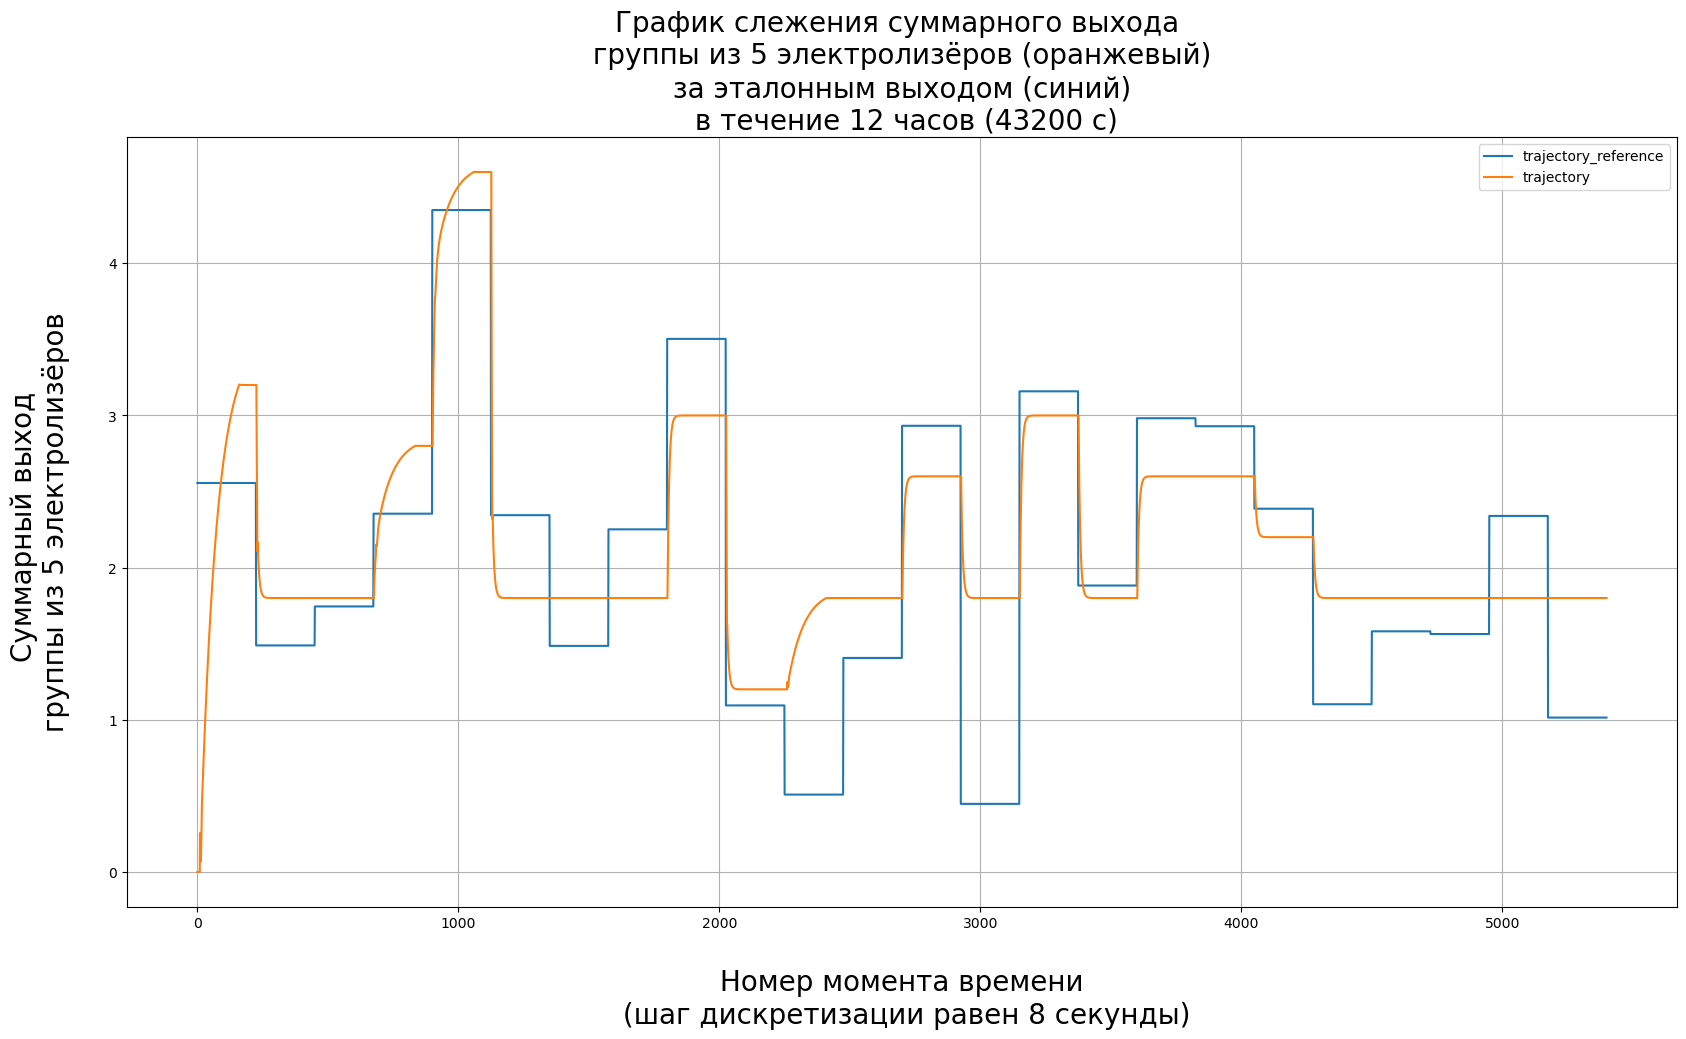

In [29]:
fig, ax = plt.subplots(figsize=(20, 10)) # (13, 6)
ax.set_title(f"График слежения суммарного выхода \n группы из {NUMBER_OF_ELECTROLYSERS} электролизёров (оранжевый) \n за эталонным выходом (синий) \n в течение {HOURS_IN_SIMULATION} часов ({HOURS_IN_SIMULATION * HOUR_TO_SEC} с)", fontsize=20)
plt.plot(trajectory_reference, label='trajectory_reference')
plt.plot(trajectory, label='trajectory')
ax.set_xlabel(f'\n Номер момента времени \n (шаг дискретизации равен {SAMPLING_TIME_PLANT} секунды)', fontsize=20)
ax.set_ylabel(f'Суммарный выход \n группы из {NUMBER_OF_ELECTROLYSERS} электролизёров \n', fontsize=20)
plt.legend()
plt.grid(visible=True)
#  Устанавливаем интервал основных делений:
# ax.xaxis.set_major_locator(ticker.MultipleLocator(15 * 60))========
#  Устанавливаем интервал вспомогательных делений:
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#  Тоже самое проделываем с делениями на оси "y":
# ax.yaxis.set_major_locator(ticker.MultipleLocator(1/2))===========
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
#  Настраиваем вид основных тиков:
# ax.tick_params(axis = 'x', labelrotation = 45) # axis = 'both',=============
# ax.tick_params(axis = 'both', labelsize = 20)================
plt.show()

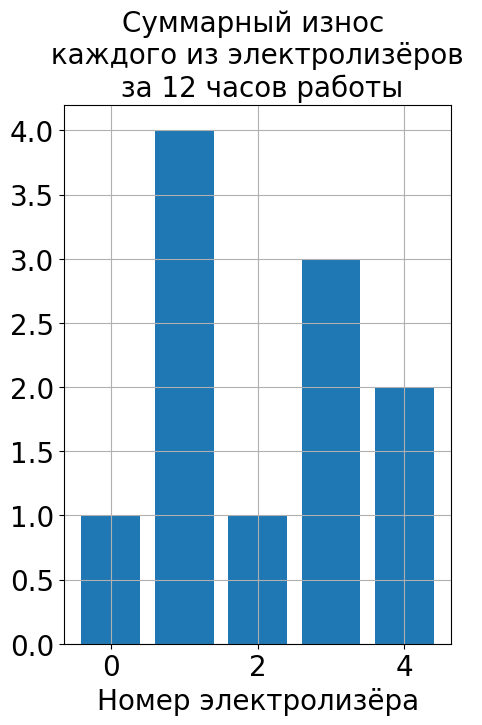

In [30]:
names = list(range(NUMBER_OF_ELECTROLYSERS))
fig, ax = plt.subplots(figsize=(5, 7))
ax.set_title(f"Суммарный износ \n каждого из электролизёров \n за {HOURS_IN_SIMULATION} часов работы", fontsize=20)
plt.bar(names, group_deterioration)  # run_out_of_elecs
# plt.bar(names, num_of_switches_neural) # run_out_of_elecs
ax.set_xlabel('Номер электролизёра', fontsize=20)
plt.grid(visible=True)
ax.tick_params(axis='x', labelrotation=0)  # axis = 'both',
ax.tick_params(axis='both', labelsize=20)
plt.show()

# Assessment of controllers of the group of electrolysers

In [56]:
## init Reference
reference = ReferenceTrajectorySource(planing_horizon_in_seconds = HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC,
                                      sampling_time_plan = SAMPLING_TIME_PLAN,
                                      sampling_time_plant = SAMPLING_TIME_PLANT,
                                      number_of_electrolysers = NUMBER_OF_ELECTROLYSERS,
                                      electrolyser_max_power = ELECTROLYSER_MAX_POWER,
                                      historical_data_path = "microgrid_data_analysis_processing/PM_tesla_PW_may22-sept22.csv", 
                                      simulation_time_in_seconds = SIMULATION_TIME)

/home/jovyan/Automated_power_management_in_hydrogen_based_microgrids/Case_Phoenix_Mews/reference_trajectrory_source_model.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)
/home/jovyan/Automated_power_management_in_hydrogen_based_microgrids/Case_Phoenix_Mews/reference_trajectrory_source_model.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'] = -grid_power['grid_power']
/home/jovyan/Automated_power_management_in_hydrogen_based_microgrids/Case_Phoenix_Mews/reference_traj

In [57]:
## init assessment
assessment = ControlAssessment(sample_time_plant = SAMPLING_TIME_PLANT, electrolyser_max_power = ELECTROLYSER_MAX_POWER)

In [58]:
def assess_control_policy_on_one_day(policy, 
                                     assessment,
                                     reference,
                                     day,
                                     steps_in_episode,
                                     number_of_electrolysers, 
                                     electrolyser_max_power, 
                                     sampling_time_plant, 
                                     sampling_time_plan, 
                                     sampling_time_control, 
                                     planing_horizon_in_seconds):
    assessment_data = {"day": [], "RMSE": [], "MSE": [], "MAE": [], "SMAPE": [], 
                       "unclaimed_energy": [], "consumed_energy": [], "energy_loss": [], 
                       "deterioration": [], "deterioration_max": [], "deterioration_mean": [], "deterioration_std": []}
    ## init Plant
    plant = GroupOfElectrolysers(number_of_electrolysers=number_of_electrolysers, sampling_time=sampling_time_plant)
    ## reference
    [year, month, day] = day
    reference.get_full_plan_from_historical_data(year, month, day)
    if reference.plan_from_historical_data is None:
        return None
    ## init Controller
    controller = Controller(policy=policy,
                            control_signal_dimension=number_of_electrolysers,
                            sampling_time_control=sampling_time_control)
    ## Episode Simulation
    [trajectory_reference,
     trajectory,
     group_deterioration,
     control_strategy]  =  episode_simulation(plant, reference, controller, steps_in_episode)
    ## Results assessment
    [Cost_episode, RMSE, J_y, J_u, J_d, MAE, SMAPE, unclaimed_energy, consumed_energy] = assessment.show_results(trajectory_reference,
                                                                                           trajectory,
                                                                                           group_deterioration,
                                                                                           control_strategy)
    assessment_data["day"] = [year, month, day]
    assessment_data["RMSE"] = RMSE
    assessment_data["MSE"] = J_y
    assessment_data["MAE"] = MAE
    assessment_data["SMAPE"] = SMAPE
    assessment_data["unclaimed_energy"] = unclaimed_energy
    assessment_data["consumed_energy"] = consumed_energy
    assessment_data["energy_loss"] = unclaimed_energy - consumed_energy
    assessment_data["deterioration"] = group_deterioration
    assessment_data["deterioration_max"] = max(group_deterioration)
    assessment_data["deterioration_mean"] = sum(group_deterioration) / number_of_electrolysers
    assessment_data["deterioration_std"] = J_d
    return assessment_data

In [24]:
import pandas as pd

In [25]:
assessment_df_heuristic_5 = pd.DataFrame({"day": [], "RMSE": [], "MSE": [], "MAE": [], "SMAPE": [], 
                       "unclaimed_energy": [], "consumed_energy": [], "energy_loss": [], 
                       "deterioration": [], "deterioration_max": [], "deterioration_mean": [], "deterioration_std": []})

In [72]:
%%time
assessment_data_list = []
for d in range(1, 30):
    print(d)
    day = [2022, 9, d]
    assessment_data = assess_control_policy_on_one_day(policy, 
                                                       assessment,
                                                       reference,
                                                       day,
                                                       STEPS_IN_EPISODE,
                                                       NUMBER_OF_ELECTROLYSERS, 
                                                       ELECTROLYSER_MAX_POWER, 
                                                       SAMPLING_TIME_PLANT, 
                                                       SAMPLING_TIME_PLAN, 
                                                       SAMPLING_TIME_CONTROL, 
                                                       HOURS_IN_PLANING_HORIZON * HOUR_TO_SEC)
    if assessment_data is None:
        continue
    assessment_data_list.append(assessment_data)  
    


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
CPU times: user 9.08 s, sys: 239 ms, total: 9.32 s
Wall time: 3.22 s


In [73]:
assessment_df_heuristic_5 = assessment_df_heuristic_5.append(assessment_data_list, ignore_index=True)

/tmp/ipykernel_16500/1790181555.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assessment_df_heuristic_5 = assessment_df_heuristic_5.append(assessment_data_list, ignore_index=True)


In [74]:
file_assessment_df = open('controllers_assessment/heuristic_results_5elec.pkl', 'wb')
pickle.dump(assessment_df_heuristic_5, file_assessment_df)
file_assessment_df.close() 

In [75]:
import pickle

In [76]:
file_assessment_df_mpc = open('controllers_assessment/heuristic_results_5elec.pkl', 'rb')
assessment_df_heuristic_5 = pickle.load(file_assessment_df_mpc)
file_assessment_df_mpc.close()

In [77]:
assessment_df_heuristic_5

,day,RMSE,MSE,MAE,SMAPE,unclaimed_energy,consumed_energy,energy_loss,deterioration,deterioration_max,deterioration_mean,deterioration_std
0,"[2022, 5, 1]",0.283304,0.080261,0.181200,0.455767,20.407434,18.603335,1.804099,"[2.0, 2.0, 0.0, 0.0, 0.0]",2.0,0.8,0.96
1,"[2022, 5, 2]",0.196439,0.038588,0.099293,0.825580,2.930354,4.866443,-1.936089,"[2.0, 0.0, 0.0, 0.0, 0.0]",2.0,0.4,0.64
2,"[2022, 5, 3]",0.001510,0.000002,0.001367,1.000000,0.039383,0.000000,0.039383,"[0, 0, 0, 0, 0]",0.0,0.0,0.00
3,"[2022, 5, 4]",0.149389,0.022317,0.053256,0.876179,3.978775,3.721704,0.257071,"[2.0, 2.0, 0.0, 0.0, 0.0]",2.0,0.8,0.96
4,"[2022, 5, 5]",0.270673,0.073264,0.137464,0.547075,23.173725,21.463954,1.709771,"[2.0, 2.0, 0.0, 0.0, 0.0]",2.0,0.8,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...
104,"[2022, 9, 24]",0.257476,0.066294,0.134507,0.624365,17.592494,18.153208,-0.560714,"[2.0, 2.0, 2.0, 0.0, 0.0]",2.0,1.2,0.96
105,"[2022, 9, 25]",0.349366,0.122057,0.205533,0.516157,29.849446,28.298392,1.551054,"[2.0, 2.0, 2.0, 0.0, 0.0]",2.0,1.2,0.96
106,"[2022, 9, 26]",0.377113,0.142214,0.209843,0.835317,9.065747,6.430383,2.635364,"[2.0, 0.0, 0.0, 0.0, 0.0]",2.0,0.4,0.64
107,"[2022, 9, 27]",0.314899,0.099162,0.124396,0.900829,3.989341,4.041565,-0.052224,"[2.0, 0.0, 0.0, 0.0, 0.0]",2.0,0.4,0.64
